<a href="https://colab.research.google.com/github/hamidb201214-svg/Lectures/blob/main/Session12_W_matrices_and_Morans_I_v3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descriptive statistics on spatial clustering

**Data:** upload `HistPat.csv` and `uspto_cpc_masterfile_1836_2016.csv` with the 📁 panel on the left (or point the paths to your Drive). The CPC file is only needed in part K. County borders are read from the US Census website.

In [1]:
%pip install -q geopandas libpysal esda mapclassify huggingface_hub

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.spatial.distance import cdist
from libpysal import weights

from huggingface_hub import hf_hub_download            # downloads once, then reuses the copy in Colab's cache
HISTPAT = hf_hub_download("HamidBekam/HistPat", "HistPat.csv", repo_type="dataset")                      # 336 MB
CPC     = hf_hub_download("HamidBekam/uspto_cpc_masterfile_1836_2000",
                          "cpc_sample_before2000.csv.gz", repo_type="dataset")                           # 9 MB, 1-in-10 sample 1836-1999, only used in part K

def moran(x, W):
    """Slide 23: I = N / (sum of all w_ij) * sum_ij w_ij z_i z_j / sum_i z_i^2, with z = x - mean."""
    z = x - x.mean()
    return len(x) / W.sum() * (z @ W @ z) / (z @ z)

row_std = lambda W: W / np.maximum(W.sum(axis=1, keepdims=True), 1e-12)   # every row sums to 1

HistPat.csv: reconstructing file:   0%|          |  0.00B /  336MB            

HistPat.csv: downloading bytes:           |  0.00B            

cpc_sample_before2000.csv.gz: reconstructing file:   0%|          |  0.00B / 9.36MB            

cpc_sample_before2000.csv.gz: downloading bytes:           |  0.00B            

## 0 · The data
Counties (map) + HistPat (patents), linked by the county code. `x` = log(1 + patents) is the variable we study.

In [2]:
counties = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_20m.zip")
counties = counties[~counties.STATEFP.isin(["02", "15", "72"])].to_crs("EPSG:5070").reset_index(drop=True)

hp = pd.read_csv(HISTPAT, encoding="latin-1", dtype={"PN": str})
hp["GEOID"] = pd.to_numeric(hp.FIPS, errors="coerce").astype("Int64").astype(str).str.zfill(5)   # 1001 or 1001.0 -> "01001"
n_pat = hp[hp.Type == "Inventor"].groupby("GEOID").PN.nunique()
counties["patents"] = counties.GEOID.map(n_pat).fillna(0)

x = np.log1p(counties.patents.to_numpy())                                # the variable of interest
xy = np.c_[counties.centroid.x, counties.centroid.y] / 1000              # centroids in km
D = cdist(xy, xy)                                                        # distance between every pair (km)
row = lambda geoid: np.flatnonzero(counties.GEOID == geoid)[0]           # county code -> row number
cook = row("17031")                                                      # Cook County (Chicago): our example
print(f"{len(hp):,} HistPat rows (complete file: 4,881,339)")
print(f"{(counties.patents > 0).sum():,} of {len(counties):,} counties have patents; Cook County: {counties.patents[cook]:,.0f}")
assert counties.patents.sum() > 0, 'No county got patents: the GEOID-FIPS merge failed - check hp.FIPS.head()'

4,881,339 HistPat rows (complete file: 4,881,339)
3,101 of 3,108 counties have patents; Cook County: 220,723


In [3]:
def show_row(w, title, ax, centre=cook, log=False, zoom=600_000):
    """Map one row of a W matrix: green = the county, red = its weights."""
    norm = LogNorm(w.max() / 1000, w.max()) if log else None
    counties.assign(w=w).plot(column="w", cmap="Reds", norm=norm, ax=ax, edgecolor="lightgrey", lw=.2)
    counties.iloc[[centre]].plot(ax=ax, color="green")
    X, Y = xy[centre] * 1000
    ax.set_xlim(X - zoom, X + zoom); ax.set_ylim(Y - .8 * zoom, Y + .8 * zoom)
    ax.set_axis_off(); ax.set_title(title)

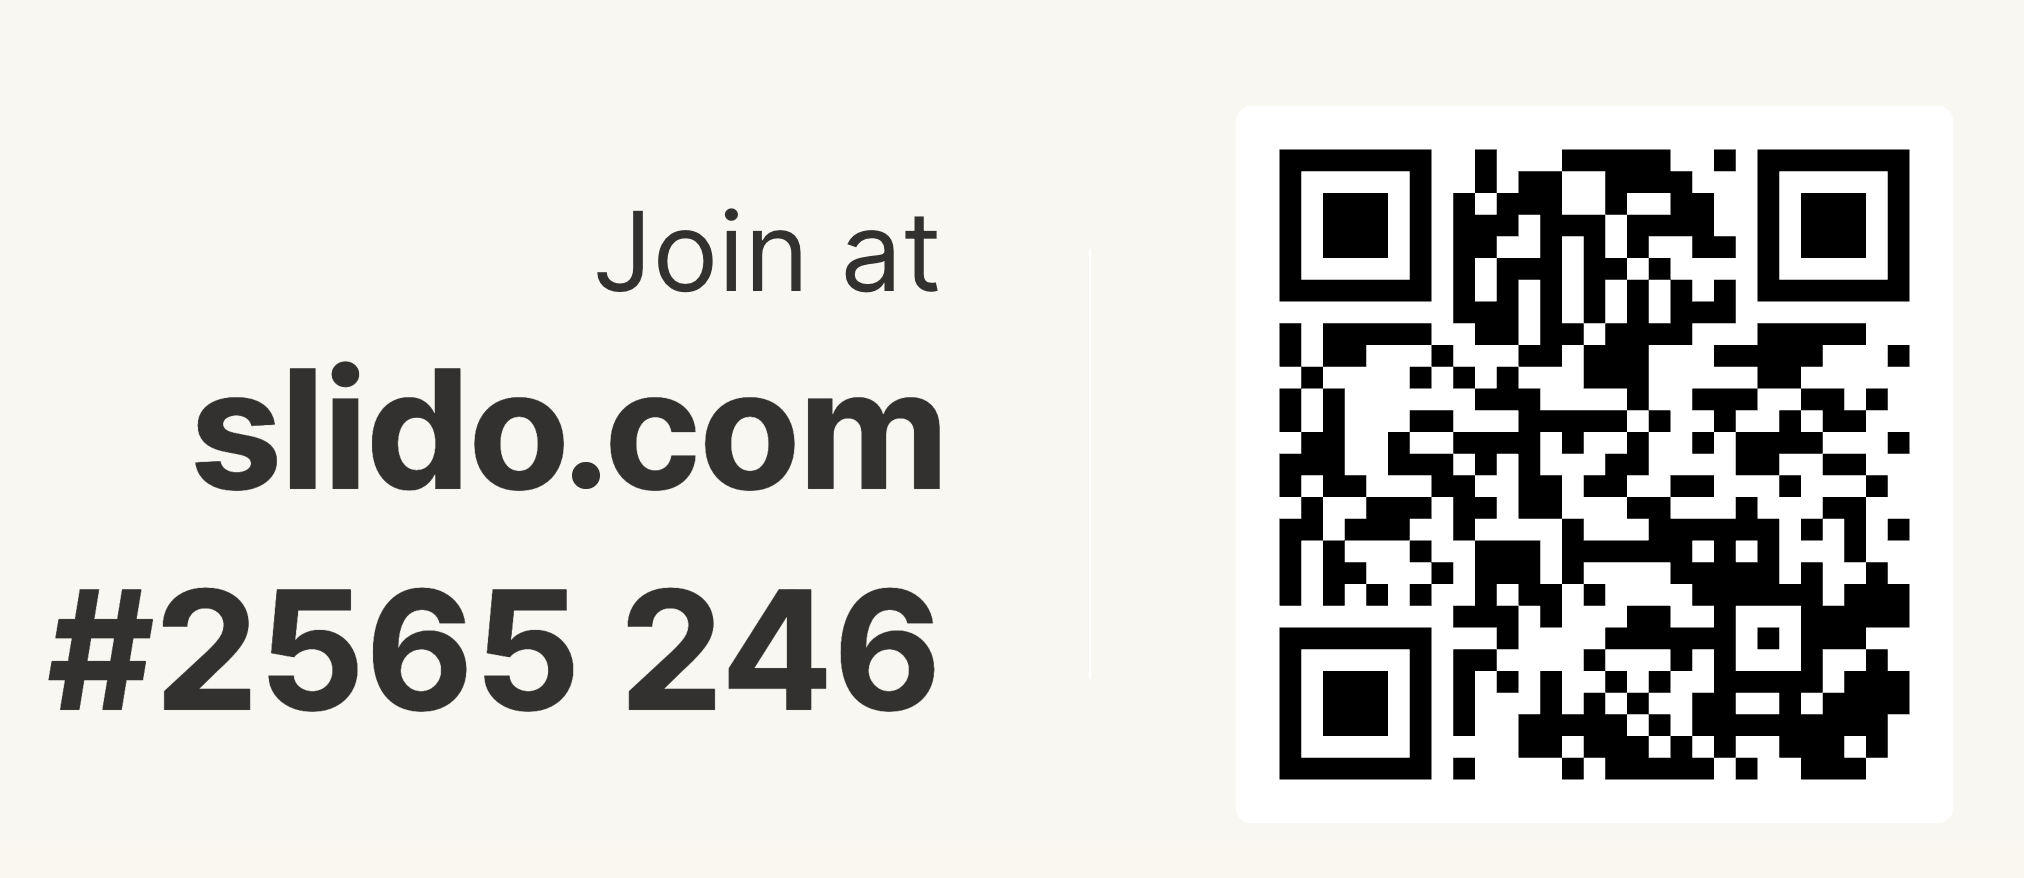

## A · Tobler's first law (1970)
*"Near things are more related than distant things."* Left: the real map. Right: the **same values shuffled** over the
counties – no geography left. If invention clusters, the real map looks smoother and its Moran's I is higher.
(Negative correlation, would look like a chessboard: rare in real data.)

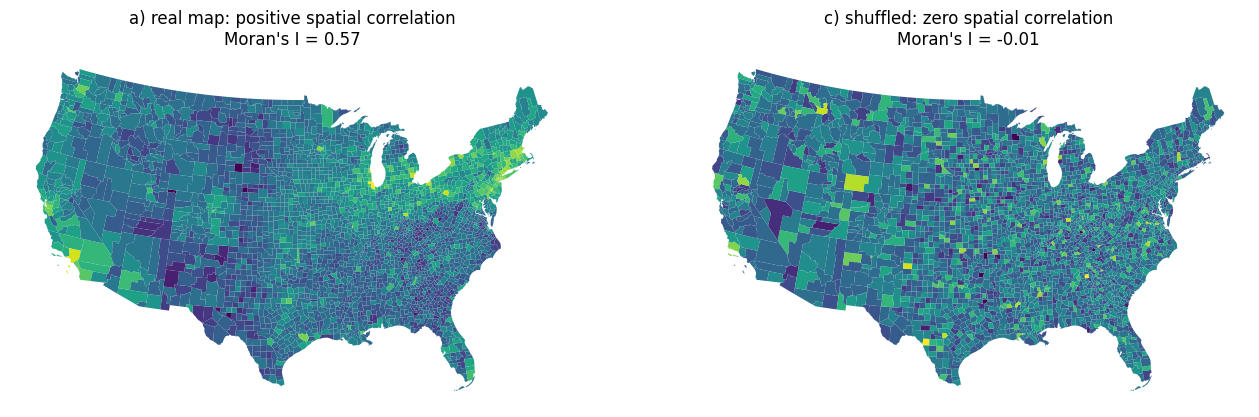

In [4]:
W_q1 = weights.Queen.from_dataframe(counties, use_index=True, silence_warnings=True).full()[0]   # neighbours = share a border
x_shuffled = np.random.default_rng(1).permutation(x)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for a, (name, v) in zip(ax, [("a) real map: positive spatial correlation", x),
                             ("c) shuffled: zero spatial correlation", x_shuffled)]):
    counties.plot(column=v, cmap="viridis", ax=a)
    a.set_axis_off(); a.set_title(f"{name}\nMoran's I = {moran(v, row_std(W_q1)):.2f}")

## B · A W matrix is a table of neighbours
Five counties around Chicago. $w_{ij}=1$ if two counties share a border, else 0 (and 0 on the diagonal).
It is the same as an adjacency matrix in a network: one line per 1.

,patents,neighbours,neighbours' average (W @ x)
Cook,220723.0,4,4682.0
DuPage,9641.0,3,75115.0
Kane,1991.0,2,115182.0
Will,2632.0,3,78276.0
Lake,4465.0,2,111678.0


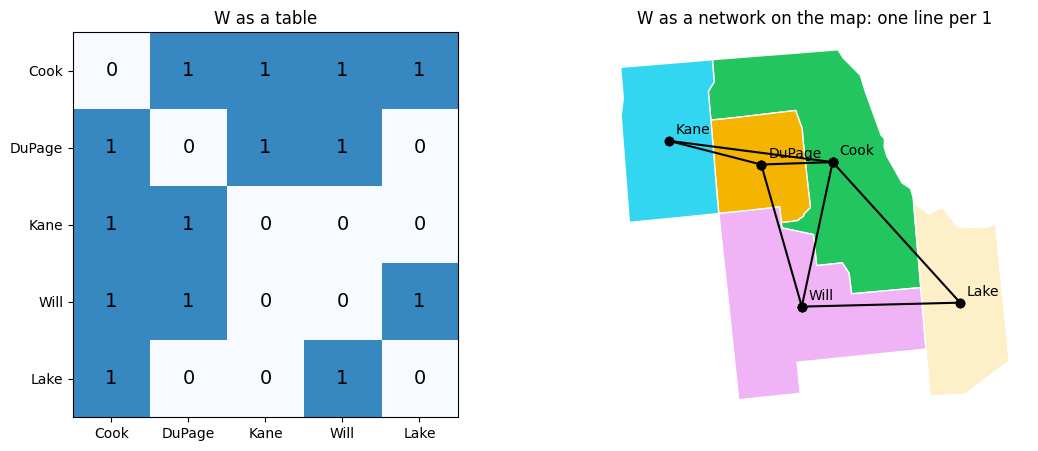

In [5]:
five = [row(g) for g in ["17031", "17043", "17089", "17197", "18089"]]   # Cook, DuPage, Kane, Will (IL), Lake (IN)
names = counties.NAME[five].tolist()
W5 = W_q1[np.ix_(five, five)].astype(int)                                  # cut the 5 x 5 piece out of the big W

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].imshow(W5, cmap="Blues", vmax=1.5)                                   # the matrix
for i in range(5):
    for j in range(5):
        ax[0].text(j, i, W5[i, j], ha="center", va="center", fontsize=14)
ax[0].set_xticks(range(5), names); ax[0].set_yticks(range(5), names); ax[0].set_title("W as a table")

counties.iloc[five].plot(ax=ax[1], color=["#22c55e", "#f5b400", "#33d6f0", "#f0b3f5", "#fdf0c8"], edgecolor="white")
for i, j in zip(*np.nonzero(np.triu(W5))):                                 # the same W as a network on the map
    ax[1].plot(*(xy[[five[i], five[j]]] * 1000).T, "k-o")
for k in five:
    ax[1].annotate(counties.NAME[k], xy[k] * 1000, xytext=(5, 5), textcoords="offset points")
ax[1].set_axis_off(); ax[1].set_title("W as a network on the map: one line per 1")

x5 = counties.patents.iloc[five].to_numpy()
pd.DataFrame({"patents": x5, "neighbours": W5.sum(axis=1),
              "neighbours' average (W @ x)": row_std(W5) @ x5}, index=names).round(0)

## C · Rook, Bishop, Queen
Like chess pieces: **Rook** = shares a border line, **Bishop** = touches only at a corner, **Queen** = either.
Corners are rare between counties – the clearest case is the **Four Corners**, where Colorado, Utah, Arizona and New Mexico meet.

links: 8773 rook + 328 bishop = 9101 queen


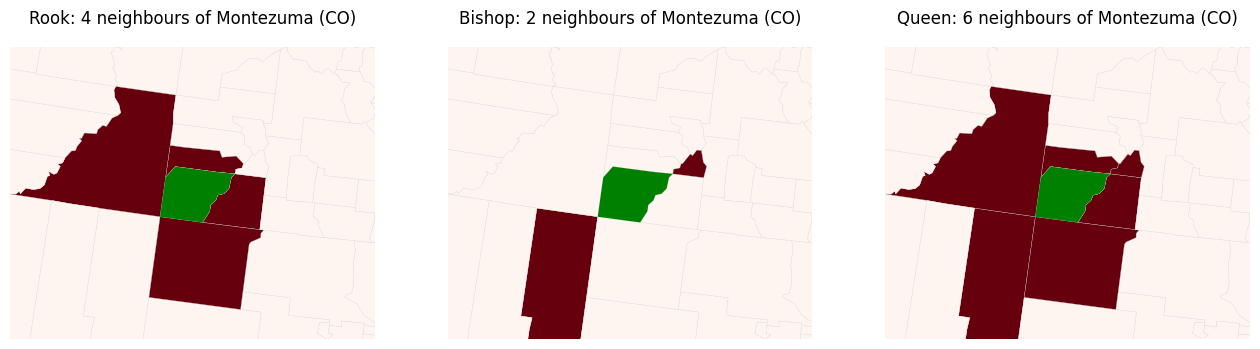

In [6]:
W_rook = weights.Rook.from_dataframe(counties, use_index=True, silence_warnings=True).full()[0]
W_bishop = W_q1 - W_rook                                                  # corner-only neighbours
mz = row("08083")                                                         # Montezuma County, Colorado

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for a, (name, W) in zip(ax, [("Rook", W_rook), ("Bishop", W_bishop), ("Queen", W_q1)]):
    show_row(W[mz], f"{name}: {int(W[mz].sum())} neighbours of Montezuma (CO)", a, centre=mz, zoom=250_000)
print("links:", int(W_rook.sum() / 2), "rook +", int(W_bishop.sum() / 2), "bishop =", int(W_q1.sum() / 2), "queen")

## D · Higher-order contiguity
2nd order = neighbours of neighbours. `A @ A` counts the 2-step paths between counties (as in networks),
so `A + A @ A > 0` = reachable in at most 2 border crossings; add `A @ A @ A` for Queen 3.

,neighbours of Cook,mean neighbours per county,Moran's I
Queen 1,6,5.9,0.574
Queen 2,16,18.4,0.514
Queen 3,32,37.8,0.473


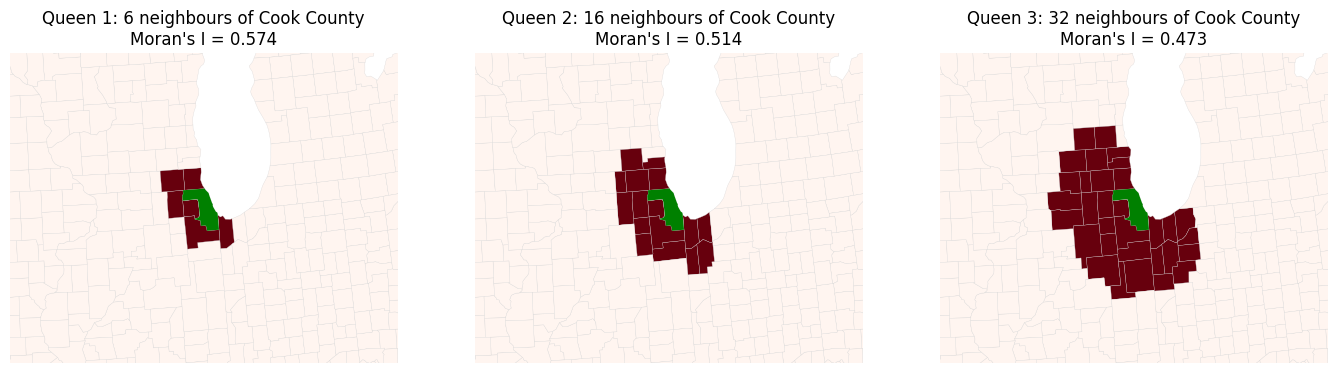

In [7]:
A = W_q1
W_q2 = ((A + A @ A) > 0) * 1.0;            np.fill_diagonal(W_q2, 0)
W_q3 = ((A + A @ A + A @ A @ A) > 0) * 1.0; np.fill_diagonal(W_q3, 0)

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
for a, (name, W) in zip(ax, [("Queen 1", W_q1), ("Queen 2", W_q2), ("Queen 3", W_q3)]):
    show_row(W[cook], f"{name}: {int(W[cook].sum())} neighbours of Cook County\nMoran's I = {moran(x, row_std(W)):.3f}",
             a, zoom=350_000)

pd.DataFrame({"neighbours of Cook": [int(W[cook].sum()) for W in (W_q1, W_q2, W_q3)],
              "mean neighbours per county": [W.sum(axis=1).mean().round(1) for W in (W_q1, W_q2, W_q3)],
              "Moran's I": [round(moran(x, row_std(W)), 3) for W in (W_q1, W_q2, W_q3)]},
             index=["Queen 1", "Queen 2", "Queen 3"])

## E · Distance band
Take a distance, choose a cut-off *d*, and include every county closer than *d*. The extent of influence can vary:
the same *d* gives many neighbours where counties are small (East) and few where they are large (West).

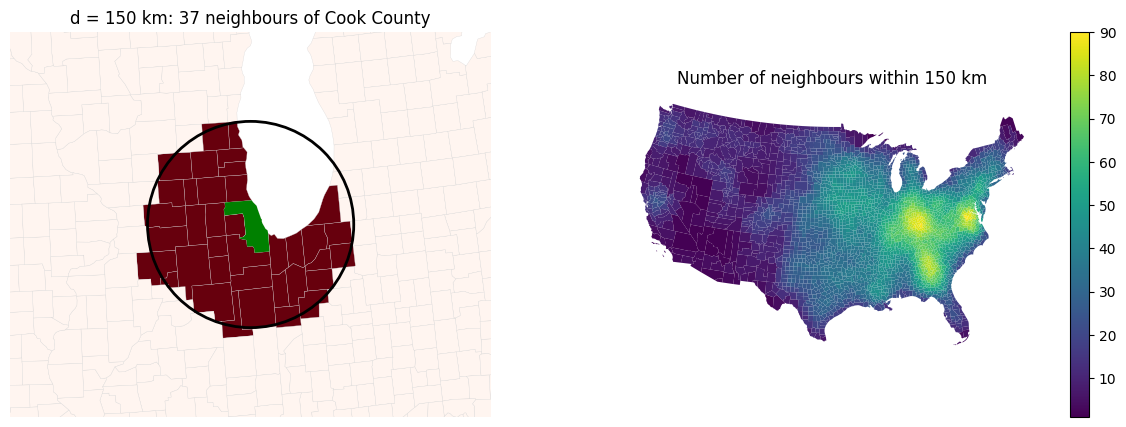

In [8]:
d = 150                                                                   # cut-off in km
W_d = ((D > 0) & (D < d)) * 1.0

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
show_row(W_d[cook], f"d = {d} km: {int(W_d[cook].sum())} neighbours of Cook County", ax[0], zoom=350_000)
ax[0].add_patch(plt.Circle(xy[cook] * 1000, d * 1000, fill=False, lw=2))
counties.plot(column=W_d.sum(axis=1), cmap="viridis", legend=True, ax=ax[1])
ax[1].set_axis_off(); ax[1].set_title(f"Number of neighbours within {d} km");

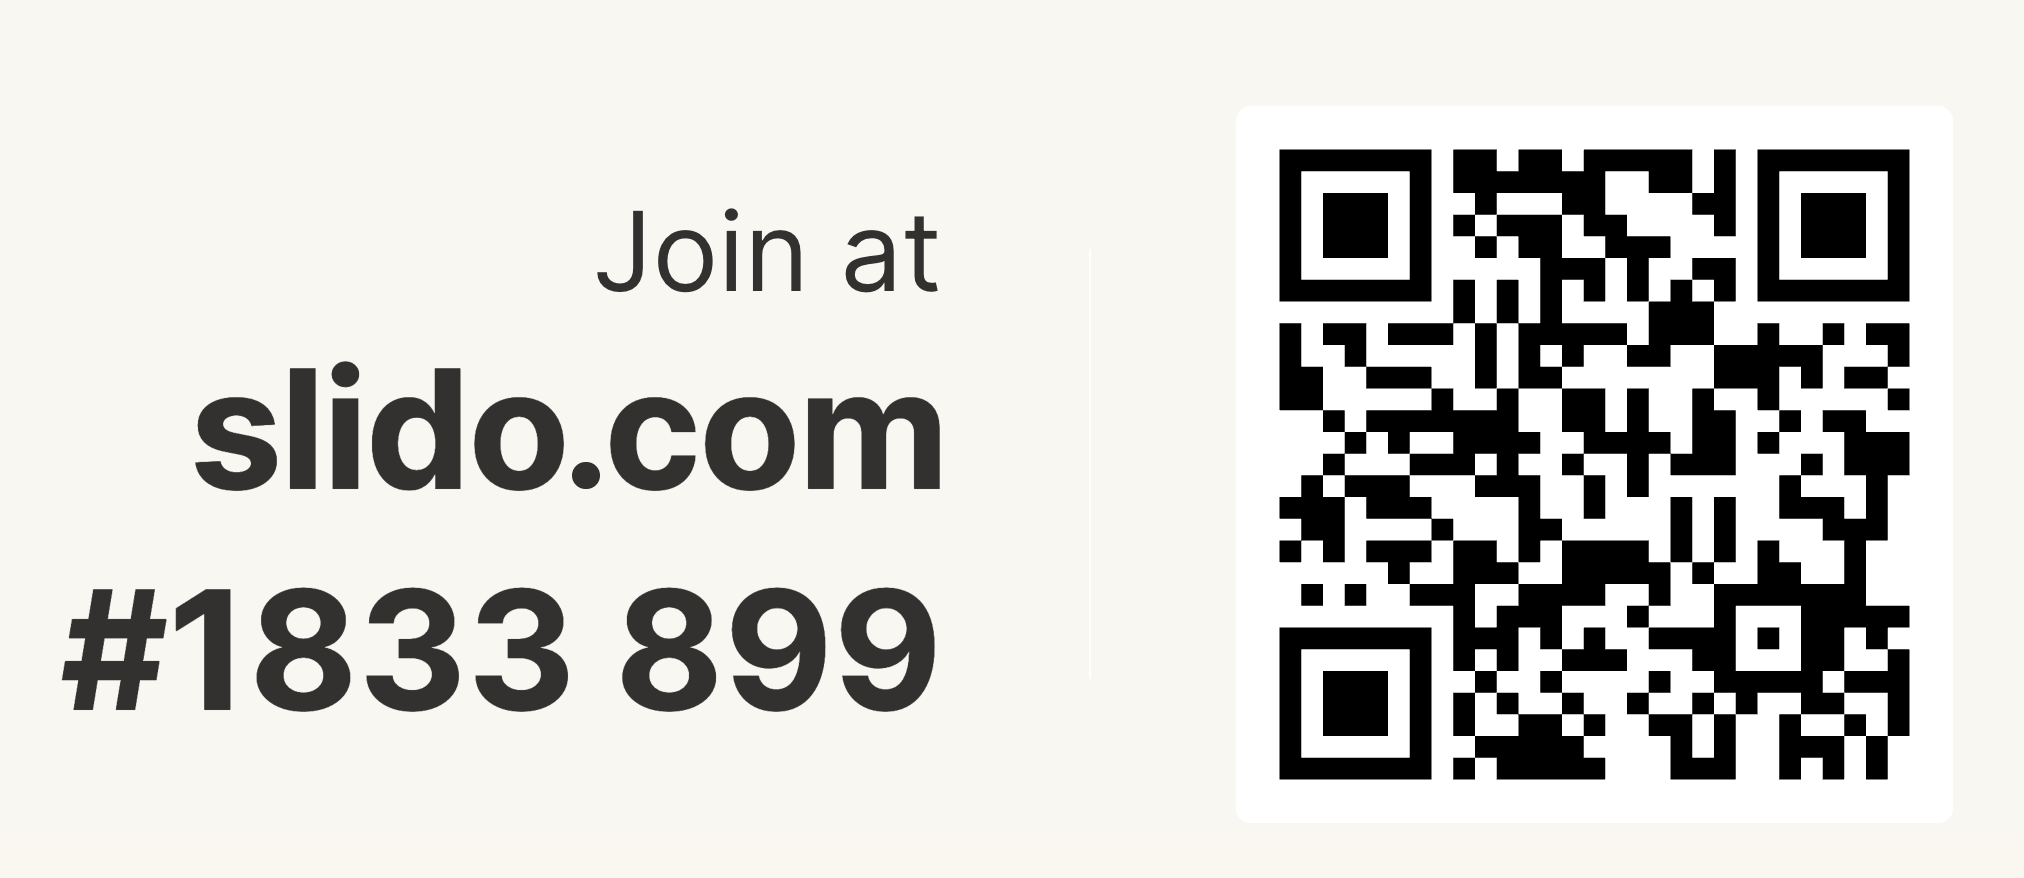

## F · Parameterising W
Instead of 0/1, let the weight **fall with distance**:
inverse distance $w_{ij}=1/d_{ij}^{\gamma}$ and negative exponential $w_{ij}=\exp(-\delta d_{ij})$ (Elhorst 2010: γ = 2, δ = 2).
Below: the weight every county gets in **Cook County's row**, against its distance from Cook. Distance in units of 100 km.

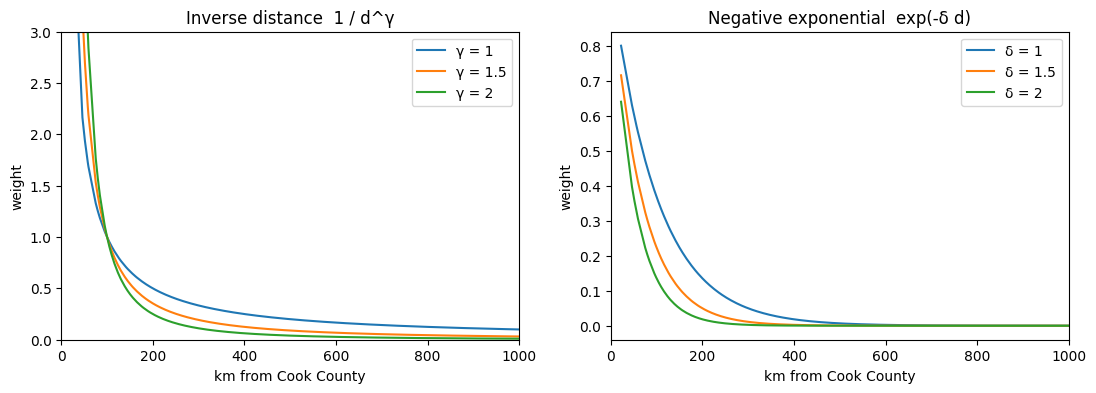

In [9]:
dc = np.sort(D[cook])[1:] / 100                                           # distances from Cook (100 km), without Cook itself

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for g in [1, 1.5, 2]:
    ax[0].plot(dc * 100, 1 / np.maximum(dc, .01) ** g, label=f"γ = {g}")
for dl in [1, 1.5, 2]:
    ax[1].plot(dc * 100, np.exp(-dl * dc), label=f"δ = {dl}")
ax[0].set(title="Inverse distance  1 / d^γ", xlabel="km from Cook County", ylabel="weight", xlim=(0, 1000), ylim=(0, 3)); ax[0].legend()
ax[1].set(title="Negative exponential  exp(-δ d)", xlabel="km from Cook County", ylabel="weight", xlim=(0, 1000)); ax[1].legend();

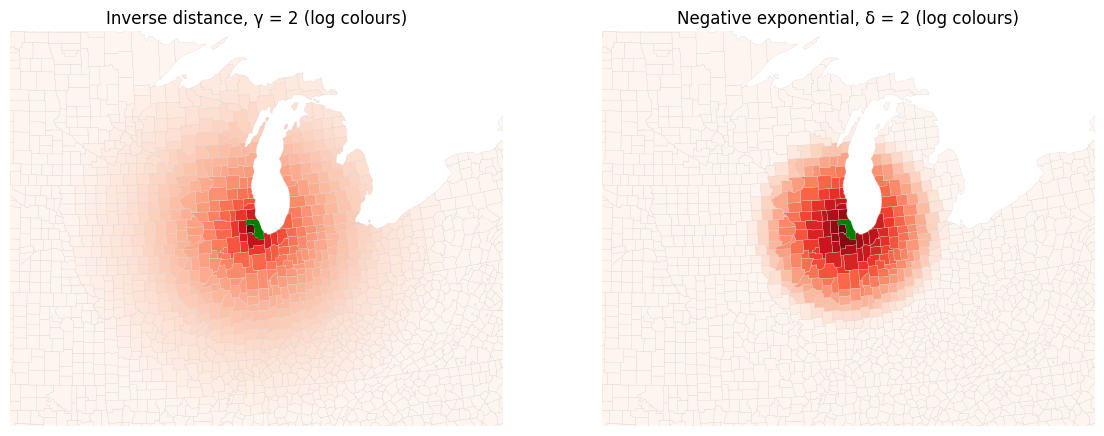

In [10]:
W_inv = np.where(D > 0, 1 / np.maximum(D / 100, 0.01) ** 2, 0)          # γ = 2
W_exp = np.where(D > 0, np.exp(-2 * D / 100), 0)                          # δ = 2

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
show_row(W_inv[cook], "Inverse distance, γ = 2 (log colours)", ax[0], log=True, zoom=900_000)
show_row(W_exp[cook], "Negative exponential, δ = 2 (log colours)", ax[1], log=True, zoom=900_000)

*Units matter:* with distances in km, `exp(-2 * 150)` is 0 for every pair. γ and δ only make sense together with the unit of distance.

## G · Moran's I, for every W
$$I=\frac{N}{W}\,\frac{\sum_i\sum_j w_{ij}(x_i-\bar x)(x_j-\bar x)}{\sum_i (x_i-\bar x)^2}$$
One line: `moran(x, W)` (defined at the top). Positive = similar values cluster. **The value depends on W.**

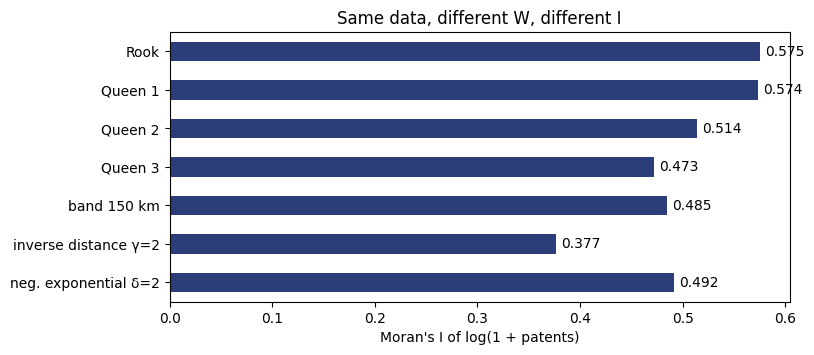

In [11]:
Ws = {"Rook": W_rook, "Queen 1": W_q1, "Queen 2": W_q2, "Queen 3": W_q3, f"band {d} km": W_d,
      "inverse distance γ=2": W_inv, "neg. exponential δ=2": W_exp}
I = pd.Series({name: moran(x, row_std(W)) for name, W in Ws.items()})

ax = I.plot.barh(figsize=(8, 3.5), color="#2c3e7a")
for k, v in enumerate(I):
    ax.text(v + .005, k, f"{v:.3f}", va="center")
ax.set_xlabel("Moran's I of log(1 + patents)"); ax.set_title("Same data, different W, different I"); ax.invert_yaxis();

## H · Moran's I is a regression slope
$W_x$ = the average of the neighbours. Regress $W_x$ on $x$: the slope *b* is Moran's I.

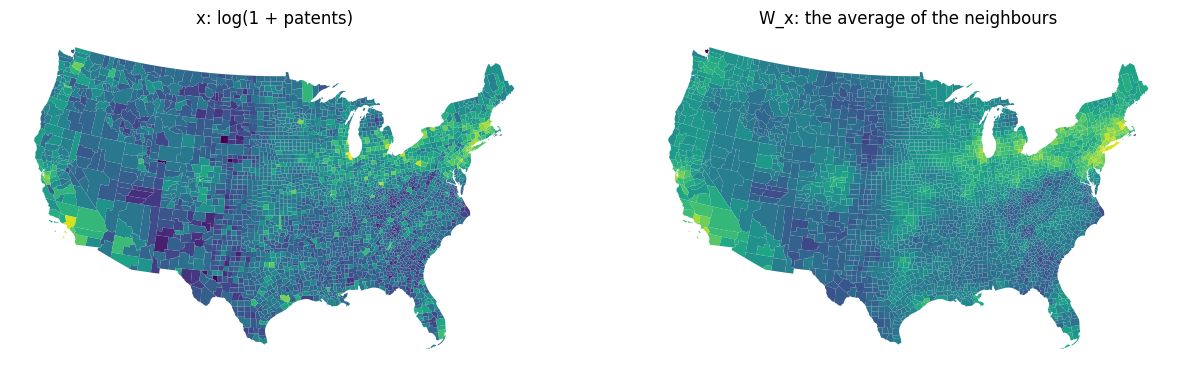

In [12]:
Wr = row_std(W_q1)
Wx = Wr @ x                                                               # average of the neighbours

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
counties.plot(column=x, cmap="viridis", ax=ax[0]); ax[0].set_title("x: log(1 + patents)")
counties.plot(column=Wx, cmap="viridis", ax=ax[1]); ax[1].set_title("W_x: the average of the neighbours")
for a in ax: a.set_axis_off()

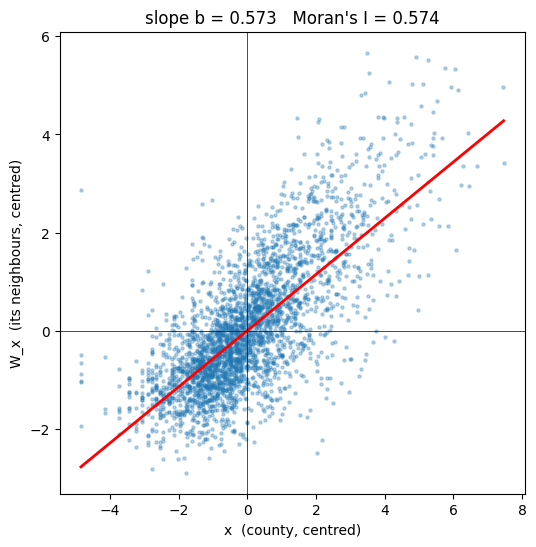

In [13]:
z, Wz = x - x.mean(), Wr @ (x - x.mean())
b = np.polyfit(z, Wz, 1)[0]                                               # the slope

plt.figure(figsize=(6, 6))
plt.scatter(z, Wz, s=5, alpha=.3)
plt.plot(np.sort(z), b * np.sort(z), color="red", lw=2)
plt.axhline(0, color="k", lw=.5); plt.axvline(0, color="k", lw=.5)
plt.xlabel("x  (county, centred)"); plt.ylabel("W_x  (its neighbours, centred)")
plt.title(f"slope b = {b:.3f}   Moran's I = {moran(x, Wr):.3f}");

Top-right = high county among high neighbours, bottom-left = low among low. Most points sit there, so the slope is positive.
(*b* and *I* differ only in the 3rd decimal because a few island counties have no neighbours.)

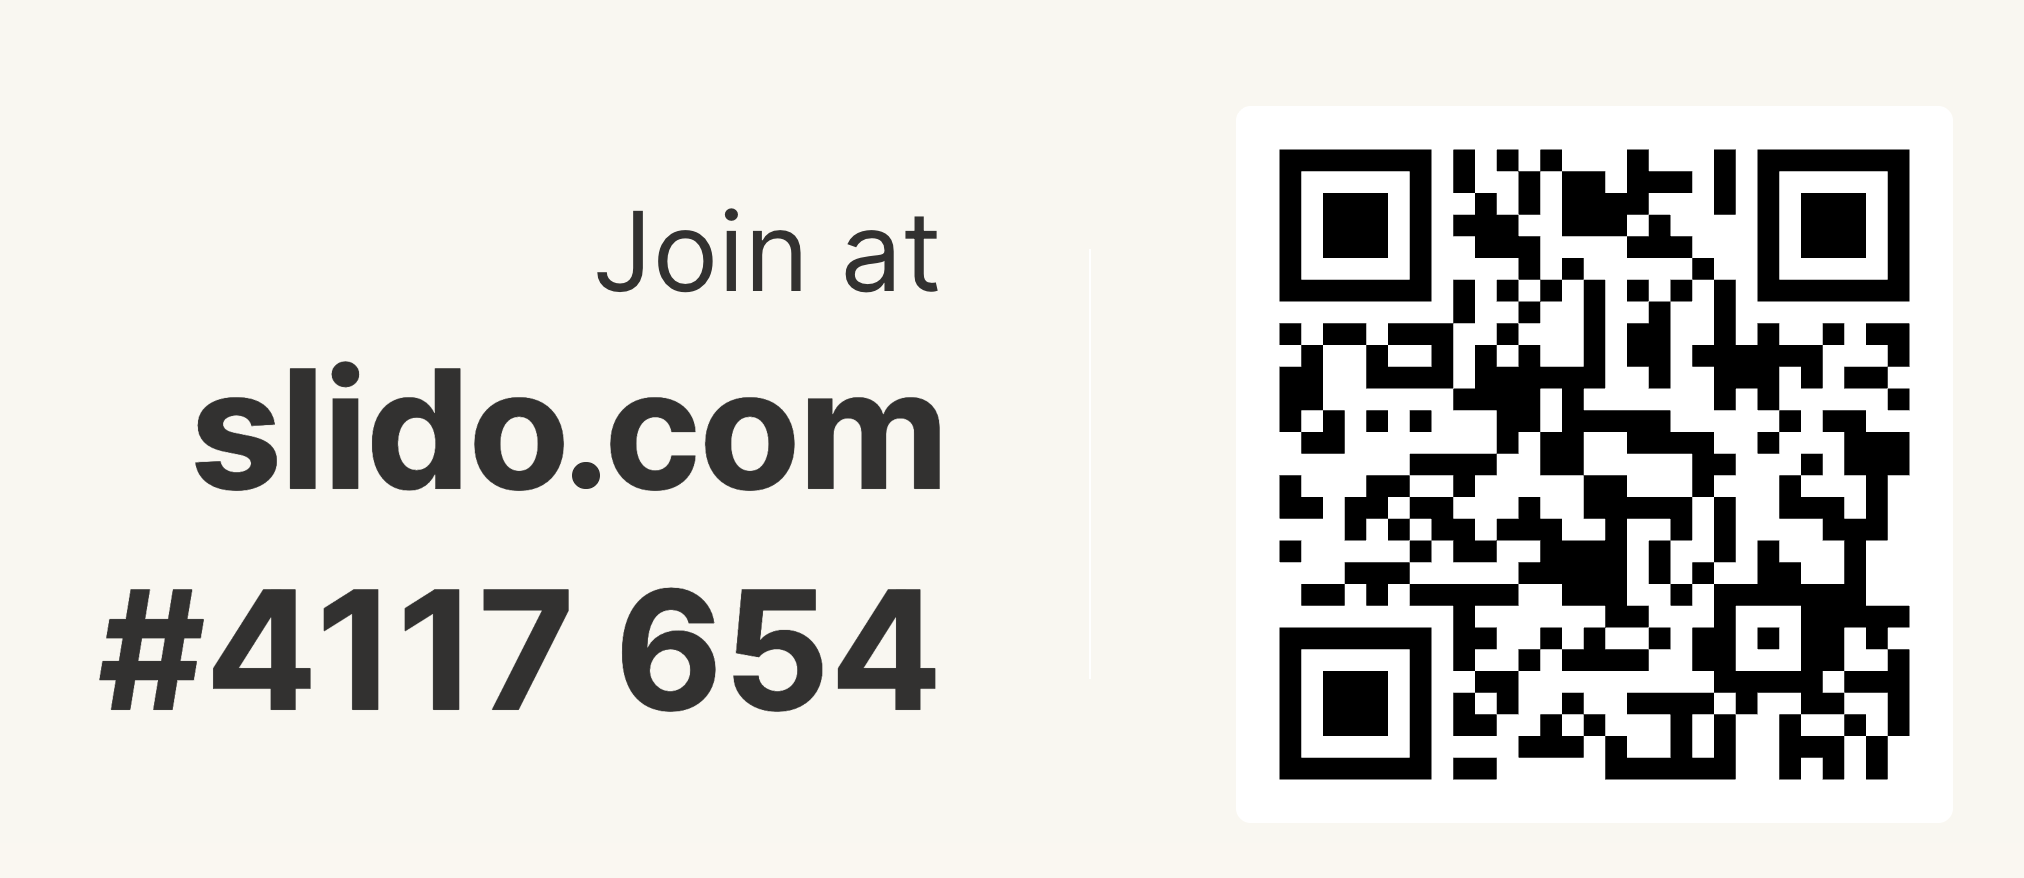

## I · A global number – where are the clusters?
Moran's I is one number for the whole map. The **local** Moran's I gives one value per county and shows *where*
the hot spots (HH) and cold spots (LL) are.

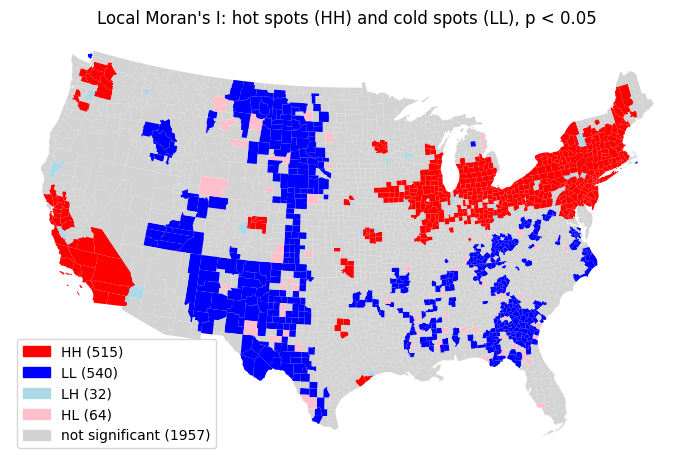

In [14]:
from esda.moran import Moran, Moran_Local
wq = weights.Queen.from_dataframe(counties, use_index=True, silence_warnings=True); wq.transform = "r"
lisa = Moran_Local(x, wq, permutations=999, seed=1)

label = np.array(["not significant", "HH", "LH", "LL", "HL"])[np.where(lisa.p_sim < 0.05, lisa.q, 0)]
colors = {"HH": "red", "LL": "blue", "LH": "lightblue", "HL": "pink", "not significant": "lightgrey"}
ax = counties.plot(color=[colors[l] for l in label], figsize=(11, 5.5))
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c, label=f"{k} ({(label == k).sum()})") for k, c in colors.items()],
          loc="lower left")
ax.set_axis_off(); ax.set_title("Local Moran's I: hot spots (HH) and cold spots (LL), p < 0.05");

## J · Is it significant?
Shuffle the values over the map many times (like map c in part A) and compute I each time.
If the real I is far outside the shuffled ones, the clustering is not chance.

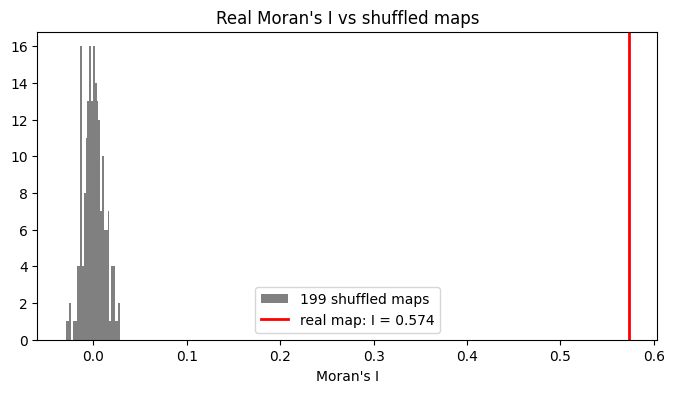

In [15]:
rng = np.random.default_rng(1)
I_real = moran(x, Wr)
I_random = [moran(rng.permutation(x), Wr) for _ in range(199)]

plt.figure(figsize=(8, 4))
plt.hist(I_random, bins=30, color="grey", label="199 shuffled maps")
plt.axvline(I_real, color="red", lw=2, label=f"real map: I = {I_real:.3f}")
plt.xlabel("Moran's I"); plt.legend(); plt.title("Real Moran's I vs shuffled maps");

In [16]:
m = Moran(x, wq)                                                          # the library version, like R's moran.test
print("Moran I test under randomisation")
p = "< 2.2e-16" if m.p_rand < 2.2e-16 else f"= {m.p_rand:.3g}"
print(f"Moran I statistic standard deviate = {m.z_rand:.2f}, p-value {p}")
print(f"Moran I statistic = {m.I:.4f}   Expectation = {m.EI:.4f}   Variance = {m.VI_rand:.6f}")
print(f"pseudo p-value from 999 shuffles = {m.p_sim}  (the smallest possible: 1/1000)")

Moran I test under randomisation
Moran I statistic standard deviate = 53.54, p-value < 2.2e-16
Moran I statistic = 0.5736   Expectation = -0.0003   Variance = 0.000115
pseudo p-value from 999 shuffles = 0.001  (the smallest possible: 1/1000)


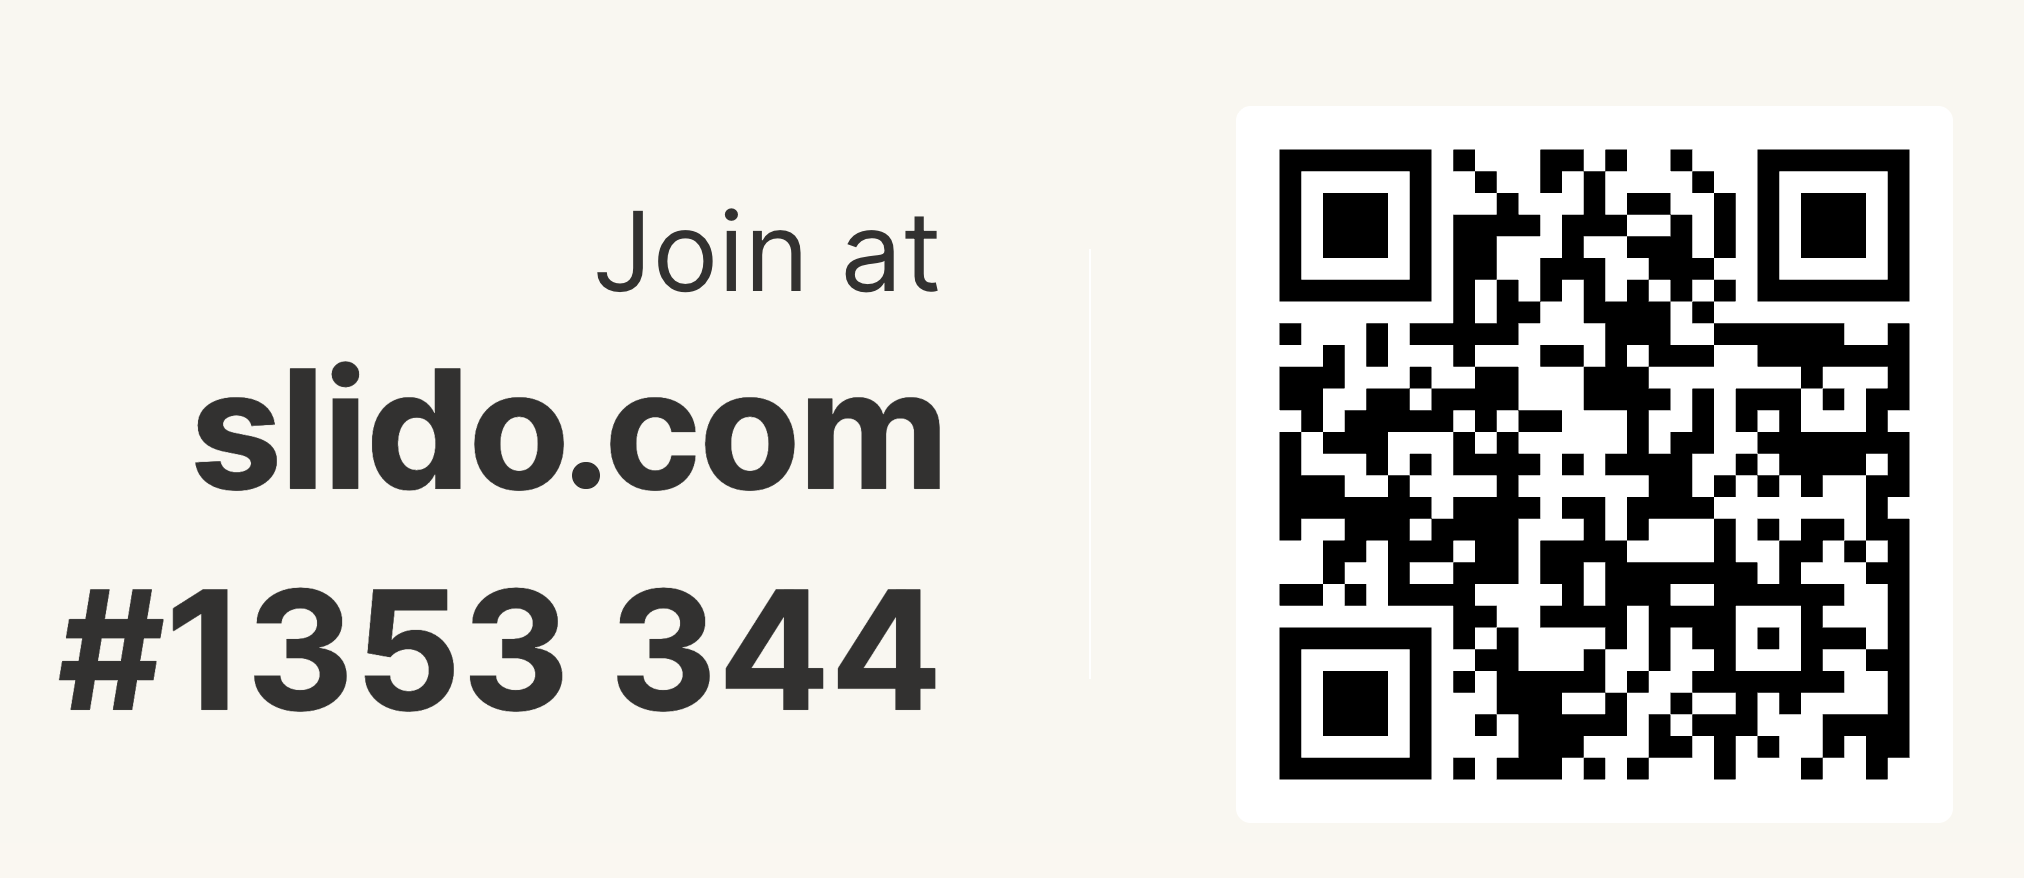

## K · Both datasets: one technology vs all invention
HistPat says **where** a patent was invented; the CPC file says **what** it is about. They share the patent number
(`00001465` in CPC = `US1465` in HistPat). Pick a CPC class, count its patents per county, and ask:
does this technology cluster **more or less** than invention overall?

In [17]:
TECH = "H04"                                                              # e.g. H04 telecom, B60 vehicles, A01 agriculture

sep = "\t" if "cpc" in pd.read_csv(CPC, sep="\t", nrows=1).columns else ","     # tab- or comma-separated
cpc = pd.concat(ch[ch.cpc.str.startswith(TECH, na=False)]                 # read in chunks, keep only TECH
                for ch in pd.read_csv(CPC, sep=sep, dtype=str, usecols=["pn", "cpc", "gyear"], chunksize=2_000_000))
cpc = cpc[pd.to_numeric(cpc.gyear, errors="coerce") <= 1975]               # HistPat ends in 1975
cpc["PN"] = "US" + cpc.pn.str.lstrip("0")                                 # 00001465 -> US1465, as in HistPat

tech = hp[(hp.Type == "Inventor") & hp.PN.isin(cpc.PN)]                   # the merge: HistPat rows of TECH patents
counties["tech"] = counties.GEOID.map(tech.groupby("GEOID").PN.nunique()).fillna(0)
x_tech = np.log1p(counties.tech.to_numpy())
print(f"{TECH}: {cpc.PN.nunique():,} patents granted by 1975 in the CPC file, {tech.PN.nunique():,} of them "
      f"({tech.PN.nunique() / cpc.PN.nunique():.0%}) with a US inventor county in HistPat, in {(counties.tech > 0).sum():,} counties")

H04: 6,863 patents granted by 1975 in the CPC file, 5,302 of them (77%) with a US inventor county in HistPat, in 454 counties


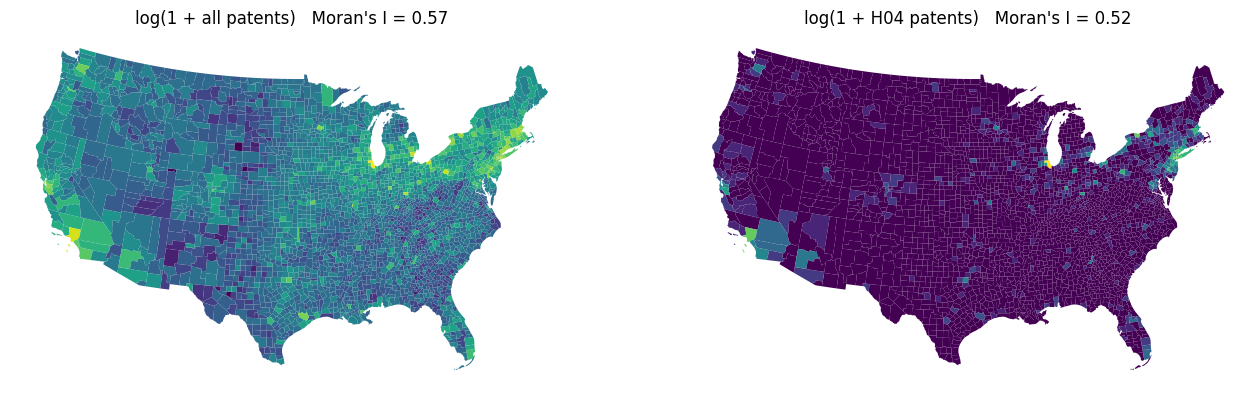

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for a, (name, v) in zip(ax, [("all patents", x), (f"{TECH} patents", x_tech)]):
    counties.plot(column=v, cmap="viridis", ax=a)
    a.set_axis_off(); a.set_title(f"log(1 + {name})   Moran's I = {moran(v, row_std(W_q1)):.2f}")

,all patents,H04
Rook,0.575,0.522
Queen 1,0.574,0.521
Queen 2,0.514,0.435
Queen 3,0.473,0.370
band 150 km,0.485,0.361
inverse distance γ=2,0.377,0.356
neg. exponential δ=2,0.492,0.406


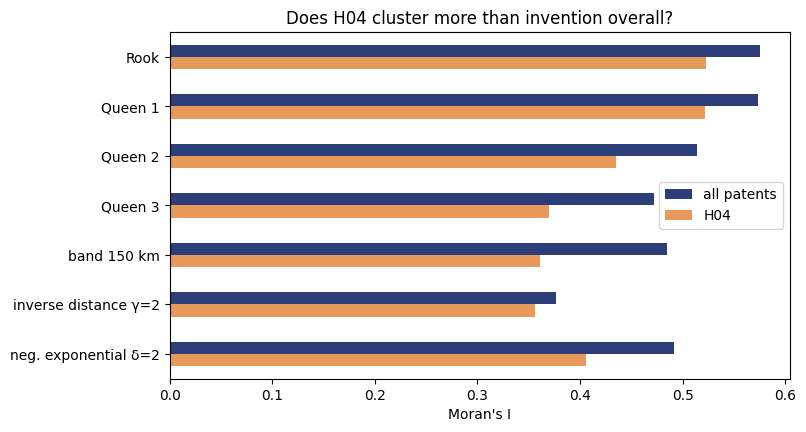

In [19]:
I_both = pd.DataFrame({"all patents": [moran(x, row_std(W)) for W in Ws.values()],
                       f"{TECH}": [moran(x_tech, row_std(W)) for W in Ws.values()]}, index=list(Ws))

ax = I_both.plot.barh(figsize=(8, 4.5), color=["#2c3e7a", "#e89a5b"])
ax.set_xlabel("Moran's I"); ax.set_title(f"Does {TECH} cluster more than invention overall?"); ax.invert_yaxis()
I_both.round(3)

**Read it:** a higher I for the technology = its inventors are more concentrated in neighbouring counties
than inventors in general. Try a few classes (e.g. `A01`, `B60`, `C07`, `H01`) – which are the most clustered?

## 🧪 Now it is your turn
*In class, and possibly this week's assignment*

### Your task
Choose a **three-digit CPC technology** that interests you (e.g. **H03: Electronic circuitry**).
Find the technology description and classification here:
[USPTO CPC scheme – section H](https://www.uspto.gov/web/patents/classification/cpc/html/cpc-H.html)
(change the letter in the link for other sections, e.g. `cpc-A.html`, `cpc-B.html`).

1. **Diffusion over time:** analyse the geographical diffusion of your technology across US counties in **10-year windows**.
   HistPat gives county locations up to **1975**, so use windows such as 1876–1885, 1886–1895, …, 1966–1975.
2. **When is a county "diffused"?** A technology counts as diffused in a county if the county has **at least 10 patents**
   in that technology during the window. Try other thresholds (e.g. 1, 5, 20) and discuss whether your results change.
3. **S-curve:** calculate and plot the diffusion S-curve, the share (or number) of counties where the technology
   is diffused, window by window.
4. **Maps and Moran's I:** for each window, map where the technology is and calculate Moran's I
   (use the `moran(x, W)` function and a W matrix from this notebook).

### Discuss
- **Diffusion stage:** at which stage of diffusion is your technology in the last window? (See slides 51–53.)
- **Stages and clustering:** is there a meaningful relationship between the diffusion stages and Moran's I?
  For example, is the technology more clustered early on and more spread out later?
- **Business implications:** what should executives do at this stage of diffusion?
  Think about where to locate R&D, where to find talent and partners, and whether to enter now or wait.

> 💡 **Tips**
> - Reuse part K: change `TECH`, then add `Year` to group the patents by window.
> - With the 1-in-10 CPC sample, counts are about one tenth of the real ones. Use a lower threshold
>   (e.g. 1 patent in the sample ≈ 10 real patents), or use the full CPC file.